In [15]:
import os
import zipfile
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

from tqdm import tqdm

from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
zip_path = "/content/drive/MyDrive/Brain Tumor Detection Model/Brain Tumor MRI images.zip"

extract_path = "/content/brain_tumor"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("Dataset Extracted")

Dataset Extracted


In [19]:
os.listdir(extract_path)

['Brain Tumor MRI images']

In [20]:
root = os.path.join(extract_path, 'Brain Tumor MRI images')

train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"
test_dir = "/content/dataset/test"

classes = ["Healthy", "Tumor"]

for folder in [train_dir,val_dir,test_dir]:
    os.makedirs(folder,exist_ok=True)

for cls in classes:

    images = os.listdir(os.path.join(root,cls))
    random.shuffle(images)

    train_size = int(len(images)*0.7)
    val_size = int(len(images)*0.15)

    train_imgs = images[:train_size]
    val_imgs = images[train_size:train_size+val_size]
    test_imgs = images[train_size+val_size:]

    for split,split_imgs in zip(
        [train_dir,val_dir,test_dir],
        [train_imgs,val_imgs,test_imgs]
    ):

        os.makedirs(os.path.join(split,cls),exist_ok=True)

        for img in split_imgs:
            shutil.copy(
                os.path.join(root,cls,img),
                os.path.join(split,cls,img)
            )

print("Dataset Split Complete")

Dataset Split Complete


In [21]:
train_transform = transforms.Compose([
    transforms.Resize((260,260)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((260,260)),
    transforms.ToTensor(),
])

In [22]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_transform)

train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=16,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=16,shuffle=False)

print(train_dataset.classes)

['Healthy', 'Tumor']


DATASET SUMMARY
Healthy   : 2000 images
Tumor     : 3000 images
--------------------------------------------------
Total Images : 5000


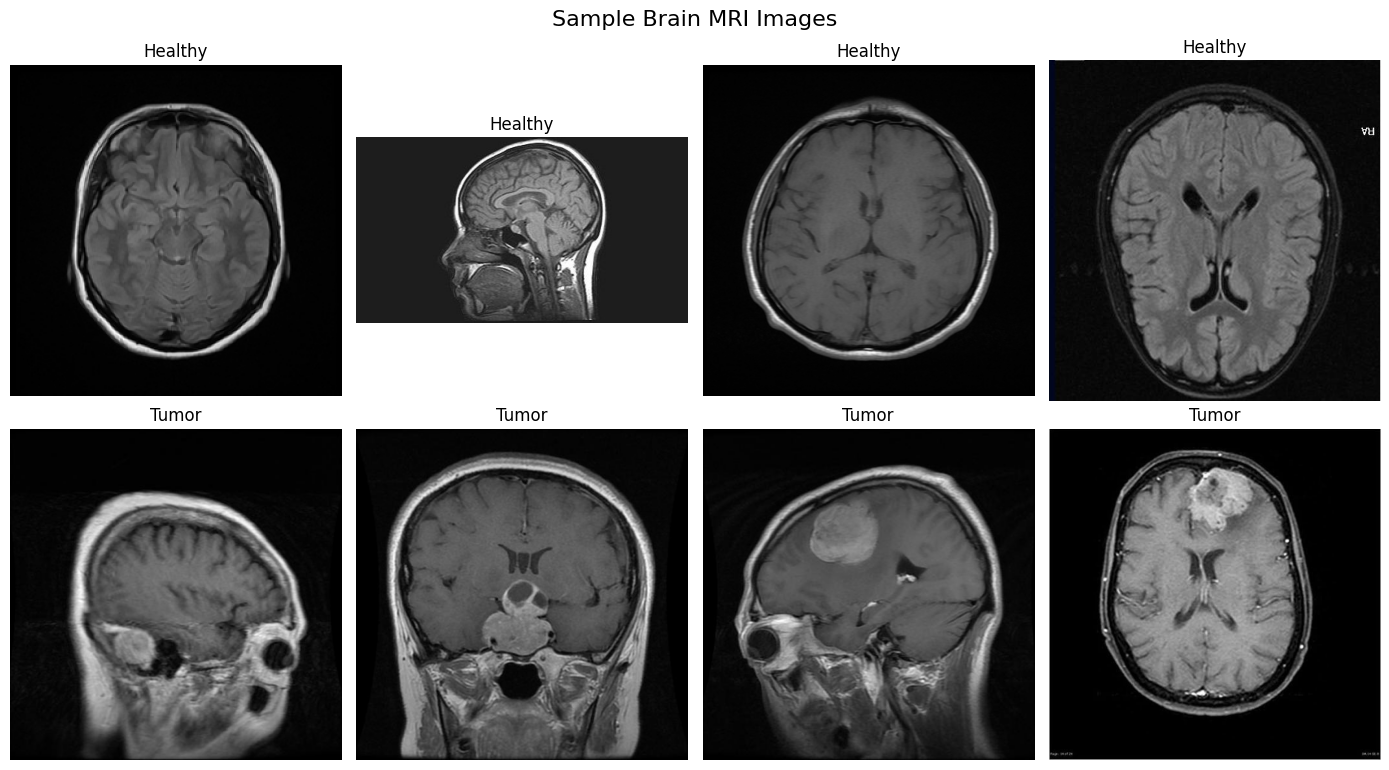

In [45]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Dataset path
dataset_path = "/content/brain_tumor/Brain Tumor MRI images"

classes = ["Healthy", "Tumor"]

print("="*50)
print("DATASET SUMMARY")
print("="*50)

total_images = 0

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    print(f"{cls:<10}: {len(images)} images")
    total_images += len(images)

print("-"*50)
print(f"Total Images : {total_images}")
print("="*50)

# -----------------------------
# Show Sample Images
# -----------------------------

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

for row, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    sample_images = random.sample(images, min(4, len(images)))

    for col, img_name in enumerate(sample_images):

        img = Image.open(os.path.join(class_path, img_name)).convert("RGB")

        axes[row, col].imshow(img)
        axes[row, col].set_title(cls)
        axes[row, col].axis("off")

plt.suptitle("Sample Brain MRI Images", fontsize=16)
plt.tight_layout()
plt.show()

In [23]:
weights = EfficientNet_B2_Weights.DEFAULT

model = efficientnet_b2(weights=weights)

num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(num_features,2)

model = model.to(device)

In [24]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=2,
    factor=0.5
)

In [25]:
class EarlyStopping:

    def __init__(self,patience=5):

        self.patience=patience
        self.counter=0
        self.best_loss=np.inf

    def step(self,val_loss):

        if val_loss<self.best_loss:

            self.best_loss=val_loss
            self.counter=0
            return False

        else:

            self.counter+=1

            if self.counter>=self.patience:
                return True

            return False


early_stopping=EarlyStopping(patience=5)

In [26]:
train_loss_history=[]
val_loss_history=[]

train_acc_history=[]
val_acc_history=[]

best_acc=0

epochs=30

for epoch in range(epochs):

    ##############################
    # TRAIN
    ##############################

    model.train()

    train_loss=0
    correct=0
    total=0

    for images,labels in tqdm(train_loader):

        images=images.to(device)
        labels=labels.to(device)

        optimizer.zero_grad()

        outputs=model(images)

        loss=criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        train_loss+=loss.item()

        _,pred=torch.max(outputs,1)

        total+=labels.size(0)

        correct+=(pred==labels).sum().item()

    train_acc=100*correct/total
    train_loss/=len(train_loader)

    ##############################
    # VALIDATION
    ##############################

    model.eval()

    val_loss=0

    correct=0
    total=0

    with torch.no_grad():

        for images,labels in val_loader:

            images=images.to(device)
            labels=labels.to(device)

            outputs=model(images)

            loss=criterion(outputs,labels)

            val_loss+=loss.item()

            _,pred=torch.max(outputs,1)

            total+=labels.size(0)

            correct+=(pred==labels).sum().item()

    val_loss/=len(val_loader)

    val_acc=100*correct/total

    scheduler.step(val_loss)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(
        f"Epoch {epoch+1} "
        f"Train Loss:{train_loss:.4f} "
        f"Val Loss:{val_loss:.4f} "
        f"Train Acc:{train_acc:.2f} "
        f"Val Acc:{val_acc:.2f}"
    )

    if val_acc>best_acc:

        best_acc=val_acc

        torch.save(model.state_dict(),"best_model.pth")

    if early_stopping.step(val_loss):

        print("Early Stopping")
        break

100%|██████████| 284/284 [01:26<00:00,  3.28it/s]


Epoch 1 Train Loss:0.1344 Val Loss:0.0084 Train Acc:95.04 Val Acc:99.86


100%|██████████| 284/284 [01:24<00:00,  3.36it/s]


Epoch 2 Train Loss:0.0255 Val Loss:0.0026 Train Acc:99.29 Val Acc:100.00


100%|██████████| 284/284 [01:24<00:00,  3.35it/s]


...

Epoch 20 Train Loss:0.0009 Val Loss:0.0001 Train Acc:99.96 Val Acc:100.00


100%|██████████| 284/284 [01:25<00:00,  3.33it/s]


Epoch 21 Train Loss:0.0016 Val Loss:0.0000 Train Acc:99.98 Val Acc:100.00


100%|██████████| 284/284 [01:24<00:00,  3.34it/s]


Epoch 22 Train Loss:0.0001 Val Loss:0.0000 Train Acc:100.00 Val Acc:100.00
Early Stopping


In [28]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [29]:
model.eval()

predictions=[]
targets=[]
probabilities=[]

with torch.no_grad():

    for images,labels in test_loader:

        images=images.to(device)

        outputs=model(images)

        probs=torch.softmax(outputs,1)

        _,pred=torch.max(outputs,1)

        predictions.extend(pred.cpu().numpy())

        probabilities.extend(probs[:,1].cpu().numpy())

        targets.extend(labels.numpy())

In [30]:
print(classification_report(
    targets,
    predictions,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       559
       Tumor       1.00      1.00      1.00       831

    accuracy                           1.00      1390
   macro avg       1.00      1.00      1.00      1390
weighted avg       1.00      1.00      1.00      1390



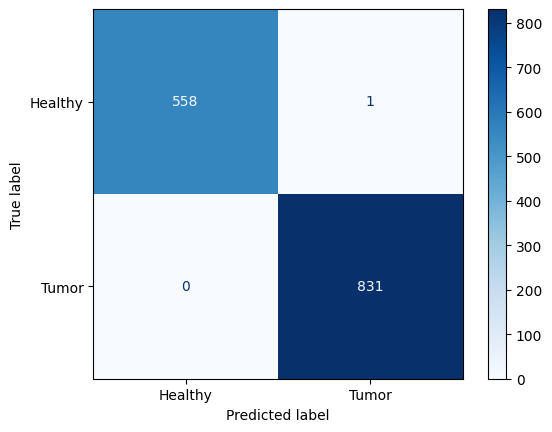

In [31]:
cm=confusion_matrix(targets,predictions)

disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(cmap="Blues")

plt.show()

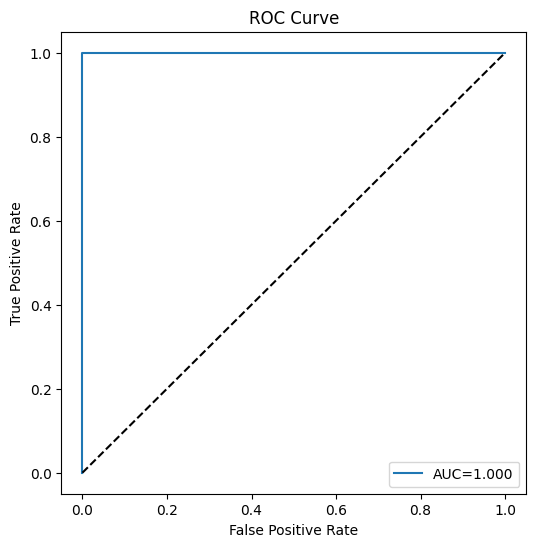

In [32]:
fpr,tpr,_=roc_curve(targets,probabilities)

roc_auc=auc(fpr,tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label=f"AUC={roc_auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

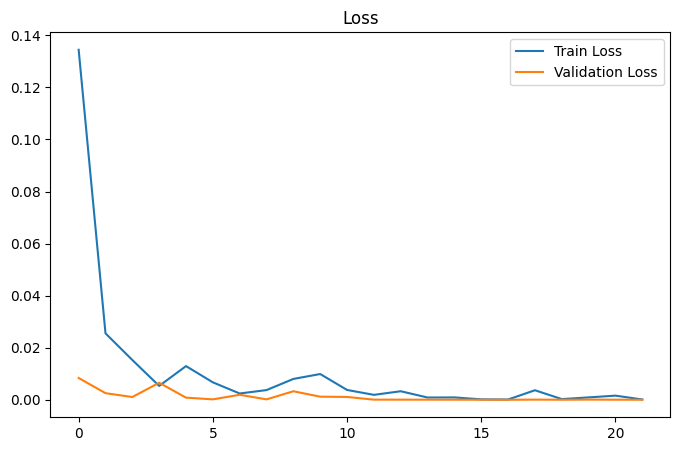

In [33]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_history,label="Train Loss")
plt.plot(val_loss_history,label="Validation Loss")

plt.legend()

plt.title("Loss")

plt.show()

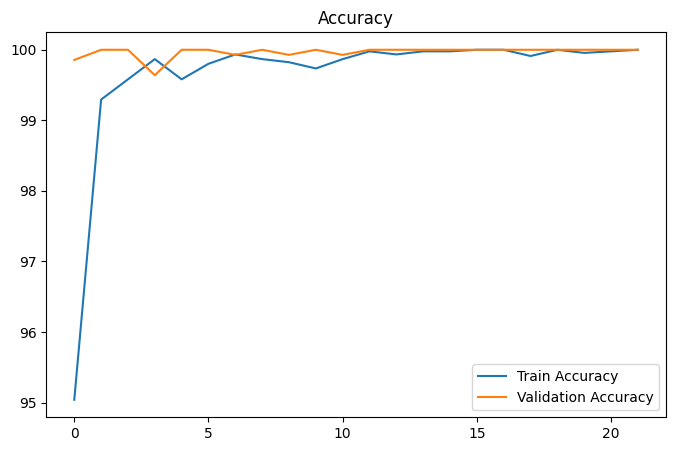

In [34]:
plt.figure(figsize=(8,5))

plt.plot(train_acc_history,label="Train Accuracy")
plt.plot(val_acc_history,label="Validation Accuracy")

plt.legend()

plt.title("Accuracy")

plt.show()

In [47]:
torch.save(model.state_dict(),"brain_tumor_efficientnetb2.pth")

In [51]:
import os

# Path to your saved model in Google Drive
model_path = "/content/drive/MyDrive/Brain Tumor Detection Model/best_model.pth"

# Check if the model exists
if os.path.exists(model_path):
    print("✅ Model Found!")
else:
    raise FileNotFoundError(f"Model not found at:\n{model_path}")

# Load checkpoint
checkpoint = torch.load(model_path, map_location=device)

# Load weights
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"✅ Loaded Best Model")
    print(f"Epoch : {checkpoint.get('epoch', 'N/A')}")
    print(f"Best Validation Accuracy : {checkpoint.get('best_val_accuracy', 'N/A')}")
else:
    model.load_state_dict(checkpoint)
    print("✅ Model Weights Loaded")

✅ Model Found!
✅ Model Weights Loaded


Saving tumor (571).jpg to tumor (571).jpg


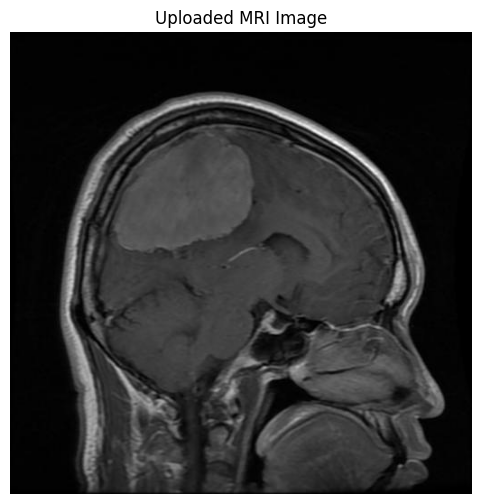

BRAIN MRI CLASSIFICATION RESULT
Predicted Class      : Tumor
Prediction Confidence: 100.00%
--------------------------------------------------
Healthy Probability  : 0.00%
Tumor Probability    : 100.00%

🔴 RESULT: Brain Tumor Detected


In [52]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

# ==========================
# Class Names
# ==========================

classes = ["Healthy", "Tumor"]

# ==========================
# Image Transform
# ==========================

transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),

    # Uncomment these if you used normalization during training
    # transforms.Normalize(
    #     mean=[0.485, 0.456, 0.406],
    #     std=[0.229, 0.224, 0.225]
    # )
])

# ==========================
# Upload Image
# ==========================

uploaded = files.upload()

image_path = next(iter(uploaded))

# ==========================
# Read Image
# ==========================

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Uploaded MRI Image")
plt.axis("off")
plt.show()

# ==========================
# Prepare Image
# ==========================

input_tensor = transform(image)
input_tensor = input_tensor.unsqueeze(0).to(device)

# ==========================
# Prediction
# ==========================

model.eval()

with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = torch.softmax(outputs, dim=1)[0]

    predicted_index = torch.argmax(probabilities).item()

# ==========================
# Results
# ==========================

healthy_prob = probabilities[0].item() * 100
tumor_prob = probabilities[1].item() * 100

predicted_class = classes[predicted_index]
confidence = probabilities[predicted_index].item() * 100

print("="*50)
print("BRAIN MRI CLASSIFICATION RESULT")
print("="*50)
print(f"Predicted Class      : {predicted_class}")
print(f"Prediction Confidence: {confidence:.2f}%")
print("-"*50)
print(f"Healthy Probability  : {healthy_prob:.2f}%")
print(f"Tumor Probability    : {tumor_prob:.2f}%")
print("="*50)

if predicted_class == "Tumor":
    print("\n🔴 RESULT: Brain Tumor Detected")
else:
    print("\n🟢 RESULT: Healthy Brain")